In [359]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [360]:
df = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\Linear_regression_4\dataset\housing_price_dataset.csv')



In [361]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [363]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [364]:
df.duplicated().sum()

0

In [365]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Neighborhood'], dtype='object')

In [366]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
numerical_features = numerical_features.drop('Price')
numerical_features

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt'], dtype='object')

In [367]:
df['Neighborhood'].unique()

array(['Rural', 'Suburb', 'Urban'], dtype=object)

In [368]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [369]:
df.head(2)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,0,1969,215355.283618
1,2459,3,2,0,1980,195014.221626


In [370]:
df.describe(include='all')

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,0.998540,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,0.815838,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,0.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,0.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2.000000,2021.000000,492195.259972


In [371]:
df[df['Price'] < 0]

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
1266,1024,2,2,2,2006,-24715.242482
2310,1036,4,1,1,1983,-7550.504574
3630,1235,3,2,0,2012,-19871.251146
4162,1352,5,2,1,1977,-10608.359522
5118,1140,4,1,2,2020,-23911.003119
5951,1097,4,3,0,1981,-4537.418615
6355,1016,5,2,0,1997,-13803.684059
8720,1235,3,1,2,1952,-24183.000515
9611,1131,3,3,2,1959,-13692.026068
10597,1177,2,3,2,2010,-434.097124


In [372]:
df['Price'] = df['Price'].abs()

In [373]:
df[df["Price"] < 0]

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price


In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  int32  
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int32(1), int64(4)
memory usage: 2.1 MB


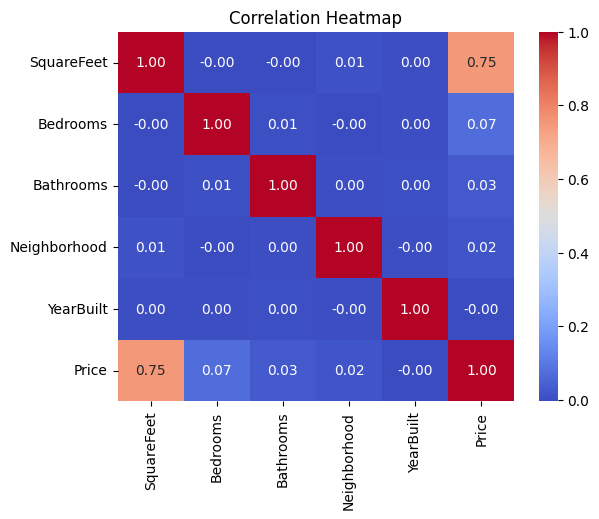

In [375]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

array([[<Axes: title={'center': 'SquareFeet'}>,
        <Axes: title={'center': 'Bedrooms'}>,
        <Axes: title={'center': 'Bathrooms'}>,
        <Axes: title={'center': 'Neighborhood'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'Price'}>, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

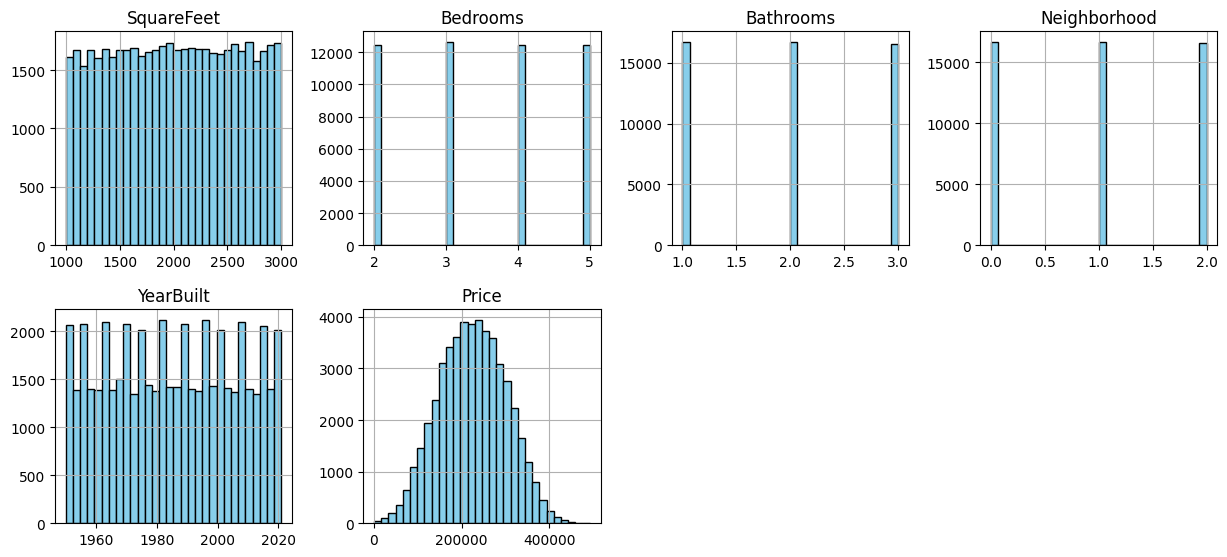

In [376]:
df.hist(bins=30, figsize=(15, 10), layout=(3, 4), color='skyblue', edgecolor='black')


In [377]:
numerical_features 

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt'], dtype='object')

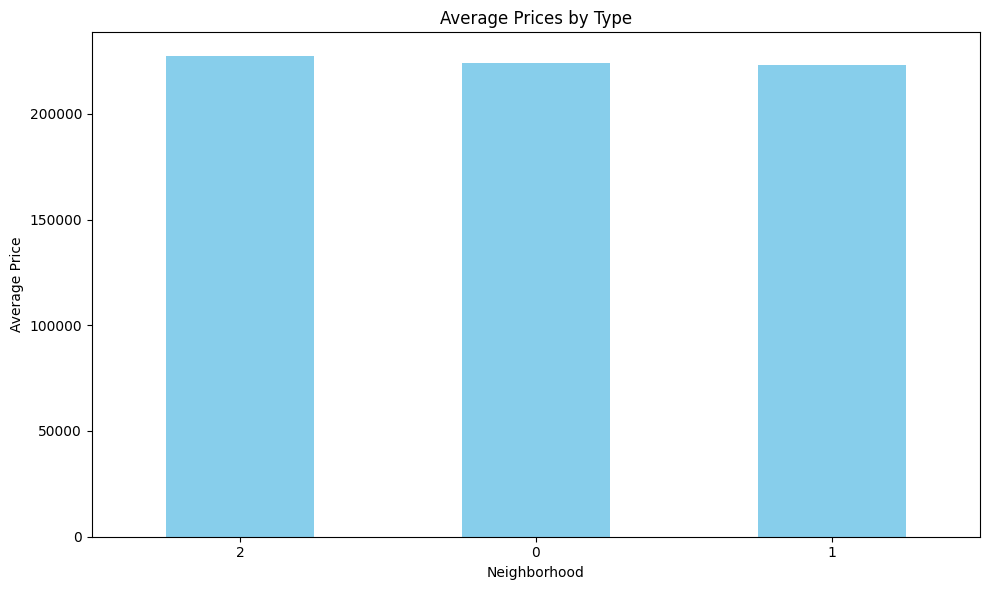

In [378]:
average_prices = df.groupby('Neighborhood')['Price'].mean().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
average_prices.plot(kind='bar', color='skyblue')
plt.title('Average Prices by Type')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [379]:
df = df.drop(columns=['Neighborhood'], axis=1)

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SquareFeet  50000 non-null  int64  
 1   Bedrooms    50000 non-null  int64  
 2   Bathrooms   50000 non-null  int64  
 3   YearBuilt   50000 non-null  int64  
 4   Price       50000 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.9 MB


In [381]:

df['Bed_Bath_Interaction'] = df['Bedrooms'] * df['Bathrooms']

df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']
df['SqFt_Per_Bedroom'] = df['SquareFeet'] / df['Bedrooms'].replace(0, 1)

In [382]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

In [383]:
for feature in numerical_features:
    print(f"skewness of {feature} is {df[feature].skew()}")

skewness of SquareFeet is -0.011161817099369262
skewness of Bedrooms is 0.004640350313677791
skewness of Bathrooms is 0.008407664728520576
skewness of YearBuilt is 0.00555654660638406
skewness of Price is -0.004975724613852437
skewness of Bed_Bath_Interaction is 0.6666786865407986
skewness of Total_Rooms is 0.00012411095718135864
skewness of SqFt_Per_Bedroom is 0.9455650029556693


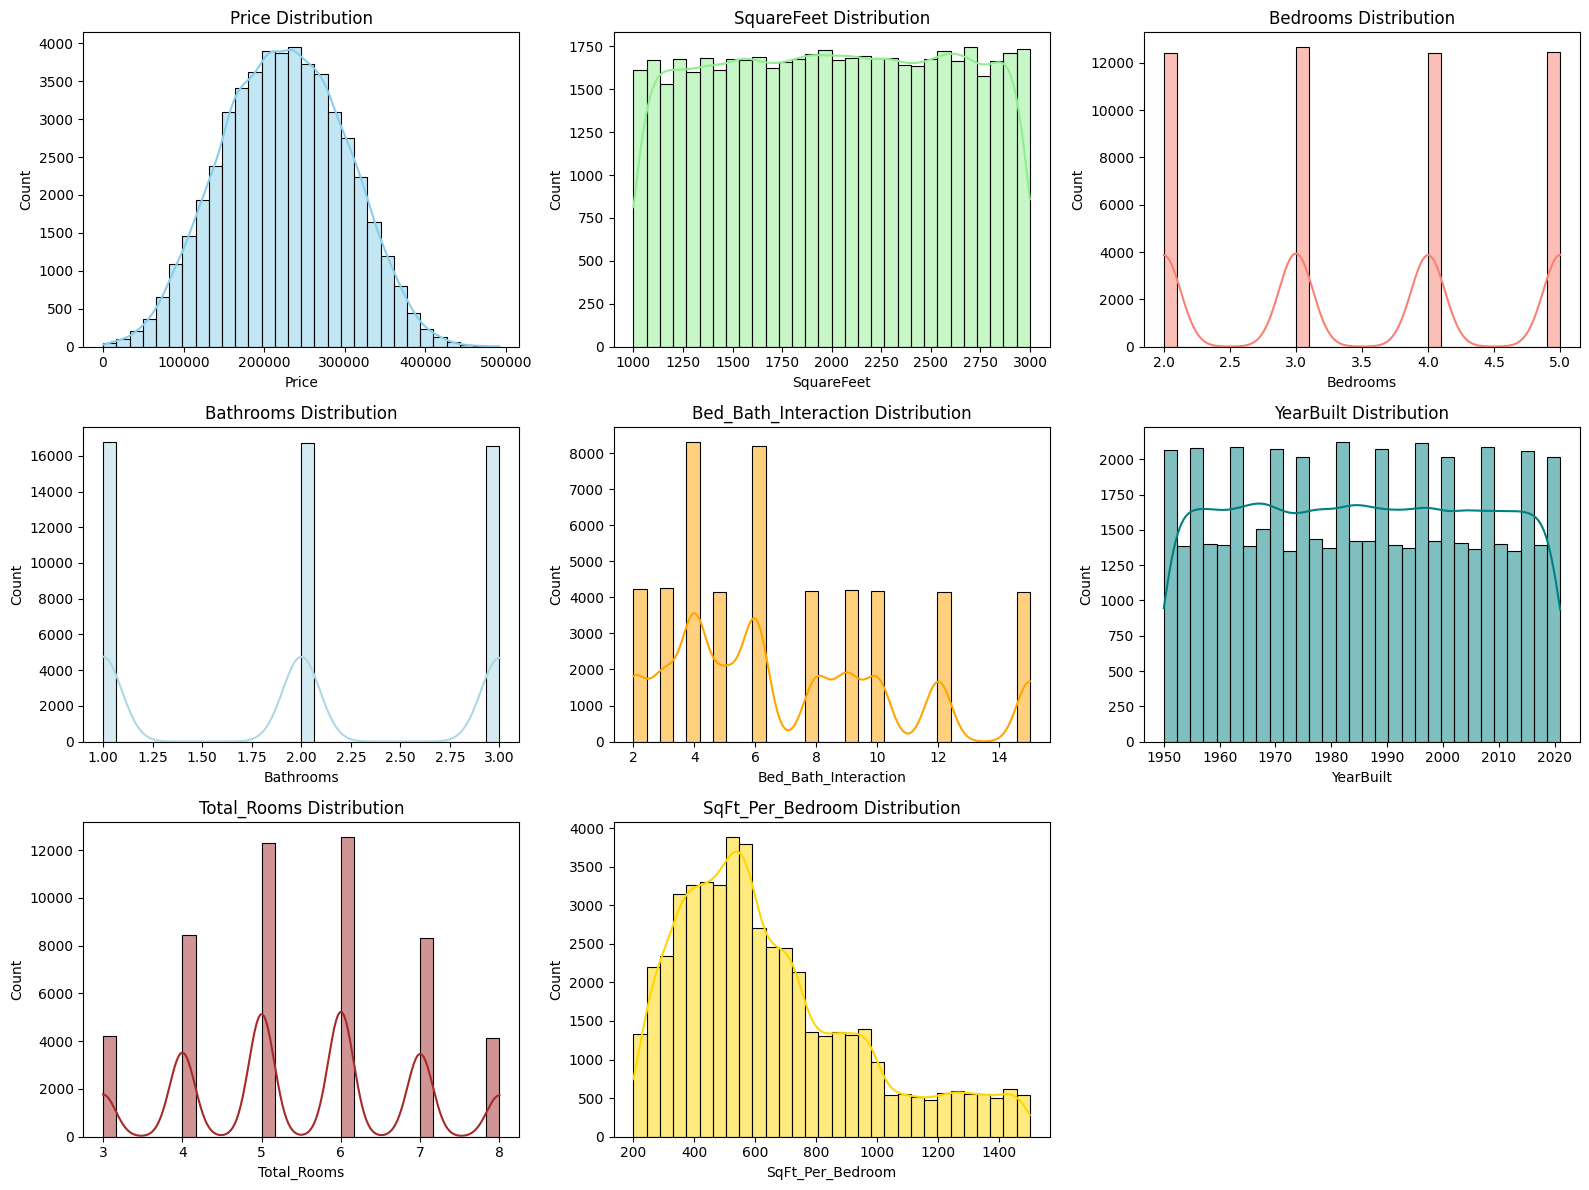

In [385]:


plt.figure(figsize=(16, 12))

# Price
plt.subplot(3, 3, 1)
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Price Distribution')

# SquareFeet
plt.subplot(3, 3, 2)
sns.histplot(df['SquareFeet'], bins=30, kde=True, color='lightgreen')
plt.title('SquareFeet Distribution')

# Bedrooms
plt.subplot(3, 3, 3)
sns.histplot(df['Bedrooms'], bins=30, kde=True, color='salmon')
plt.title('Bedrooms Distribution')

# Bathrooms
plt.subplot(3, 3, 4)
sns.histplot(df['Bathrooms'], bins=30, kde=True, color='lightblue')
plt.title('Bathrooms Distribution')

# Bed_Bath_Interaction
plt.subplot(3, 3, 5)
sns.histplot(df['Bed_Bath_Interaction'], bins=30, kde=True, color='orange')
plt.title('Bed_Bath_Interaction Distribution')


# YearBuilt
plt.subplot(3, 3, 6)
sns.histplot(df['YearBuilt'], bins=30, kde=True, color='teal')
plt.title('YearBuilt Distribution')

# Total_Rooms
plt.subplot(3, 3, 7)
sns.histplot(df['Total_Rooms'], bins=30, kde=True, color='brown')
plt.title('Total_Rooms Distribution')

# SqFt_Per_Bedroom
plt.subplot(3, 3, 8)
sns.histplot(df['SqFt_Per_Bedroom'], bins=30, kde=True, color='gold')
plt.title('SqFt_Per_Bedroom Distribution')

plt.tight_layout()
plt.show()


In [386]:
df['Log_Bed_Bath_Interaction'] = np.log1p(df['Bed_Bath_Interaction'])
df['Log_SqFt_Per_Bedroom'] = np.log1p(df['SqFt_Per_Bedroom'])


In [387]:
df = df.drop(columns=['Bed_Bath_Interaction', 'SqFt_Per_Bedroom'], axis=1)

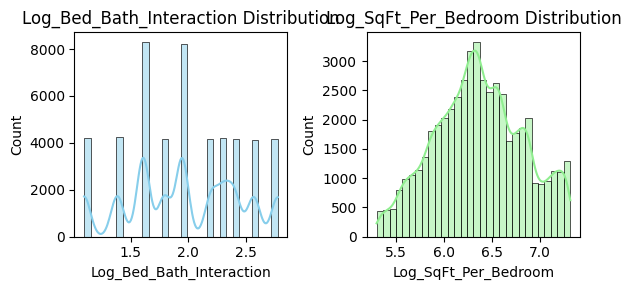

In [388]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['Log_Bed_Bath_Interaction'], bins=30, kde=True, color='skyblue')
plt.title('Log_Bed_Bath_Interaction Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['Log_SqFt_Per_Bedroom'], bins=30, kde=True, color='lightgreen')
plt.title('Log_SqFt_Per_Bedroom Distribution')
plt.tight_layout()
plt.show()

In [394]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
numerical_features

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price',
       'Total_Rooms', 'Log_Bed_Bath_Interaction', 'Log_SqFt_Per_Bedroom'],
      dtype='object')

In [392]:
df.columns


Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price',
       'Total_Rooms', 'Log_Bed_Bath_Interaction', 'Log_SqFt_Per_Bedroom'],
      dtype='object')

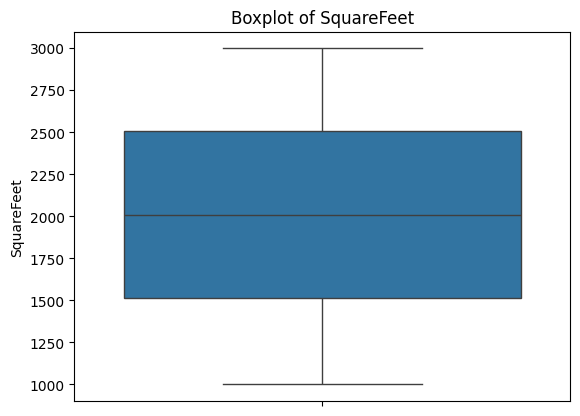

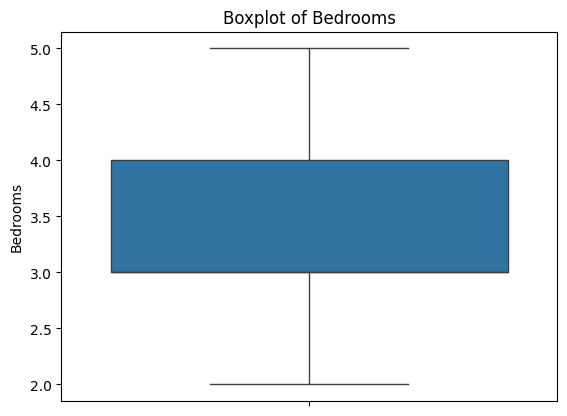

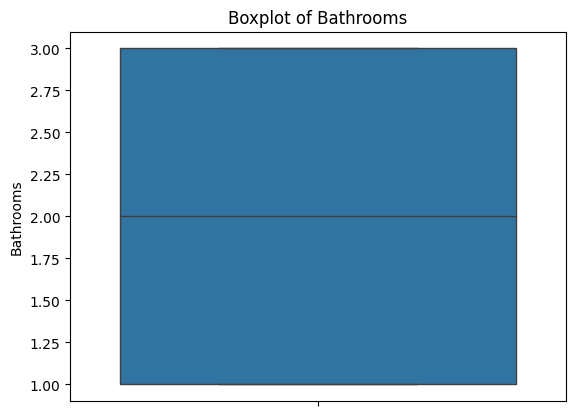

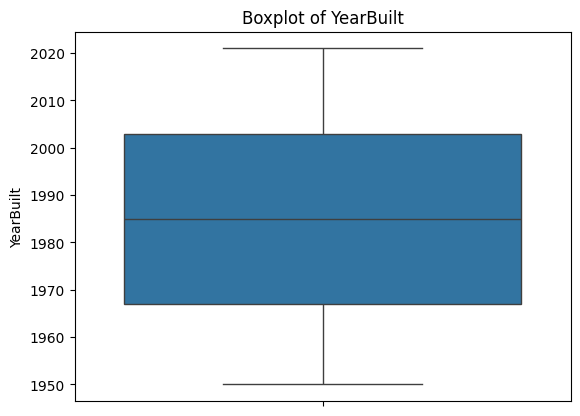

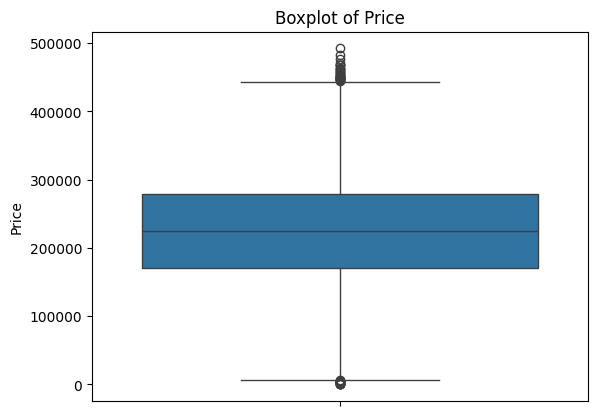

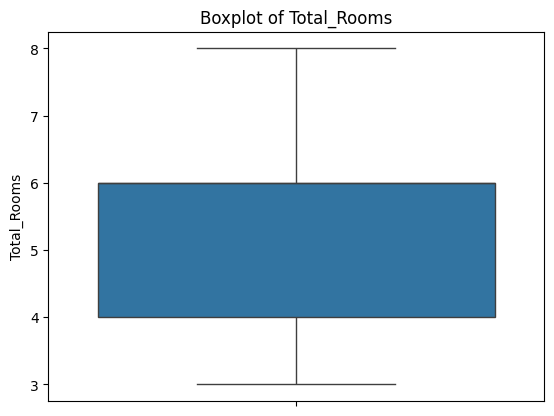

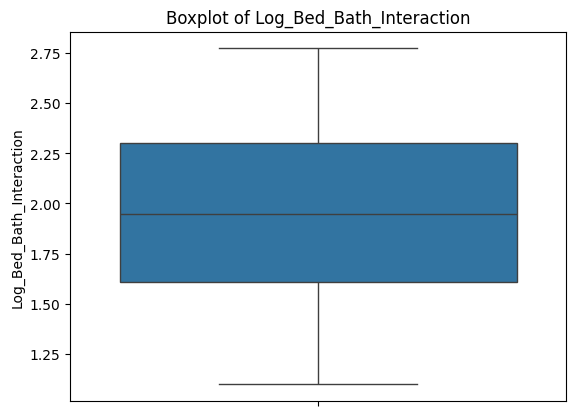

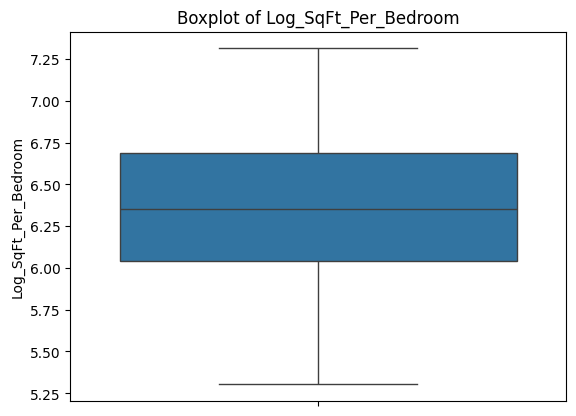

In [395]:
for col in df[numerical_features]:
    sns.boxplot(data=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

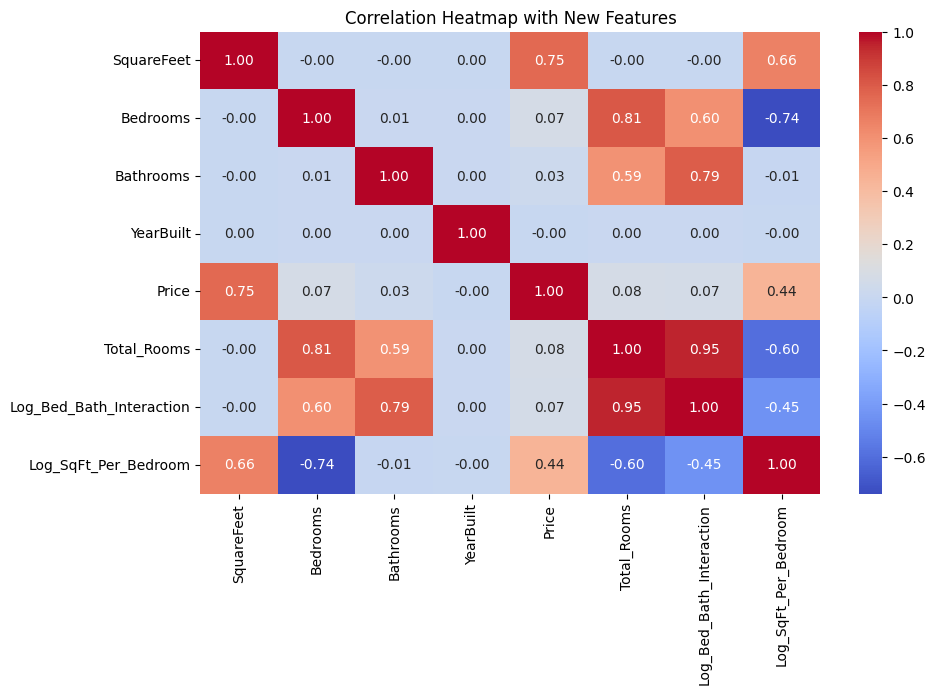

In [396]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap with New Features')
plt.show()

In [397]:
X = df.drop("Price",axis = 1)
y = df["Price"]

In [398]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numerical_features = numerical_features.drop('Price')

In [399]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [400]:

from sklearn import metrics
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)




In [402]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Assuming y_test and y_pred are already defined
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print all metrics
print("Metrices for test data:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")




Metrices for test data:
MAE: 39430.6784
MSE: 2435608099.2582
RMSE: 49351.8804
R²: 0.5755


In [404]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42,max_depth=5)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)    

# Print all metrics
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")    
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 39490.5002
MSE: 2444014819.2436
RMSE: 49436.9783
R²: 0.5740


In [405]:
print(f"The Test acc: {rf_model.score(X_test,y_test)*100}")
print(f"The Train acc: {rf_model.score(X_train,y_train)*100}")

The Test acc: 57.40122105329644
The Train acc: 57.13013354749697


In [411]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor()
grid_search = GridSearchCV(rf, param_grid, scoring='r2', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)


Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best R2: 0.5664374003327269


In [412]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=5, min_samples_split=5, n_estimators=200)

In [413]:
y_pred = best_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print("Test MAE:", mae_test)
print("Test MSE:", mse_test)
print("Test RMSE:", rmse_test)
print("Test R2:", r2_test)


Test MAE: 39494.31726645359
Test MSE: 2444323251.592721
Test RMSE: 49440.09760905333
Test R2: 0.5739584512785003


In [408]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
linear_model_poly = LinearRegression()
linear_model_poly.fit(X_train_poly, y_train)
y_pred_poly = linear_model_poly.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)    
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")    
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 39738.1484
MSE: 2470144590.5729
RMSE: 49700.5492
R²: 0.5695


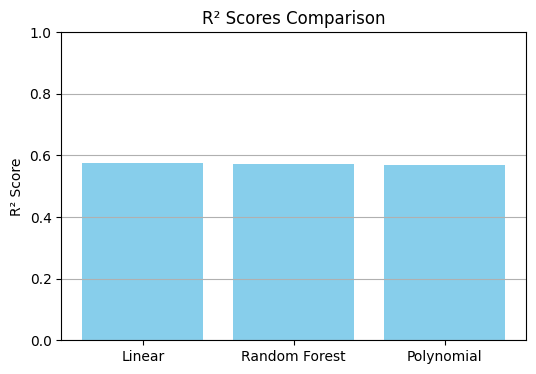

In [ ]:

models = ['Linear', 'Random Forest', 'Polynomial']
r2_scores = [0.5755, 0.5739, 0.5695]
# mae_scores = [39430.6784, 39494.3173, 39738.1484]
# rmse_scores = [49351.8804, 49440.0976, 49700.5492]
# mse_scores = [2435608099.2582, 2444323251.592721, 2470144590.5729]

# Plot: R² Scores
plt.figure(figsize=(6,4))
plt.bar(models, r2_scores, color='skyblue')
plt.title("R² Scores Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)  # R² is between 0 and 1
plt.grid(axis='y')
plt.show()


